In [52]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict
from collections import defaultdict
from tqdm import tqdm

# ═══════════════════════════════════════════════════════════
# БАЗОВЫЕ КЛАССЫ СИСТЕМЫ
# ═══════════════════════════════════════════════════════════

@dataclass
class SystemParams:
    mint_commission: float = 0.015625
    burn_commission: float = 0.015625
    mining_ev: float = -0.125
    mine_limit: float = 0.125

class ParadoxMaster:
    def __init__(self, initial_ton: float = 1, initial_prdx: float = 1000):
        self.ton_reserve = initial_ton
        self.prdx_supply = initial_prdx
        self.start_price = self.current_price()
        self.params = SystemParams()
       
        # История для графиков
        self.history = {
            'ton_reserve': [initial_ton],
            'prdx_supply': [initial_prdx],
            'price': [self.start_price],
            'mine_operations': [],  # [(deposit, reward, profit)]
        }
   
    def current_price(self) -> float:
        """Базовый курс PRDX/TON"""
        return self.ton_reserve / self.prdx_supply
   
    def estimate_mint(self, ton_amount: float) -> Tuple[float, float]:
        """Оценка операции Mint"""
        ton_to_reserve = ton_amount * (1 - self.params.mint_commission)
        prdx_amount = ton_to_reserve * self.prdx_supply / self.ton_reserve
        return prdx_amount, ton_to_reserve
   
    def estimate_burn(self, prdx_amount: float) -> Tuple[float, float]:
        """Оценка операции Burn"""
        prdx_to_burn = prdx_amount * (1 - self.params.burn_commission)
        ton_amount = prdx_to_burn * self.ton_reserve / self.prdx_supply
        return ton_amount, prdx_to_burn
   
    def estimate_mine(self, prdx_deposit: float, outcomes_count: int) -> List[float]:
        """Оценка возможных исходов Mine"""
        min_reward = (2 * prdx_deposit * (1 + self.params.mining_ev)) / (outcomes_count + 1)
        return [min_reward * (2 ** i) for i in range(outcomes_count)]
   
    def record_snapshot(self):
        """Записываем текущее состояние системы"""
        self.history['ton_reserve'].append(self.ton_reserve)
        self.history['prdx_supply'].append(self.prdx_supply)
        self.history['price'].append(self.current_price())

class TonWallet:
    def __init__(self, balance: float):
        self.balance = balance
        self.initial_balance = balance  # Для отслеживания чистых изменений

class InvestmentTracker:
    """Трекер инвестиций для точного расчета ROI"""
    def __init__(self):
        self.total_ton_invested: float = 0.0      # Всего TON введено в систему
        self.total_ton_withdrawn: float = 0.0     # Всего TON выведено из системы
        self.current_ton_in_system: float = 0.0   # Текущая стоимость позиции в TON
        
    def record_investment(self, ton_amount: float):
        """Запись новой инвестиции"""
        self.total_ton_invested += ton_amount
        self.current_ton_in_system += ton_amount
        
    def record_withdrawal(self, ton_amount: float):
        """Запись вывода средств"""
        self.total_ton_withdrawn += ton_amount
        # Уменьшаем текущую позицию пропорционально
        if self.current_ton_in_system > 0:
            withdrawal_ratio = min(ton_amount / self.current_ton_in_system, 1.0)
            self.current_ton_in_system *= (1 - withdrawal_ratio)
        
    def update_current_value(self, current_value_ton: float):
        """Обновление текущей стоимости позиции"""
        self.current_ton_in_system = current_value_ton
        
    def get_roi(self) -> float:
        """Расчет общего ROI с учетом выведенных средств"""
        if self.total_ton_invested <= 0:
            return 0.0
            
        total_value = self.total_ton_withdrawn + self.current_ton_in_system
        net_profit = total_value - self.total_ton_invested
        return net_profit / self.total_ton_invested
    
    def get_funds_ratio_in_system(self) -> float:
        """Доля средств, оставшихся в системе (от внесенных)"""
        if self.total_ton_invested <= 0:
            return 0.0
        return self.current_ton_in_system / self.total_ton_invested

class ParadoxWallet:
    def __init__(self):
        self.balance = 0.0
        self.investment_tracker = InvestmentTracker()
   
    def get_current_roi(self, system: ParadoxMaster) -> float:
        """Текущий ROI с учетом выведенных средств"""
        # Оцениваем текущую позицию в TON
        if self.balance > 0:
            current_ton_value, _ = system.estimate_burn(self.balance)
            self.investment_tracker.update_current_value(current_ton_value)
        
        return self.investment_tracker.get_roi()
    
    def get_funds_ratio_in_system(self, system: ParadoxMaster) -> float:
        """Доля средств, оставшихся в системе"""
        if self.balance > 0:
            current_ton_value, _ = system.estimate_burn(self.balance)
            self.investment_tracker.update_current_value(current_ton_value)
        
        return self.investment_tracker.get_funds_ratio_in_system()

class User:
    def __init__(self, ton_balance: float):
        self.ton_wallet = TonWallet(ton_balance)
        self.prdx_wallet = ParadoxWallet()
        self.initial_ton_balance = ton_balance  # Сохраняем начальный баланс
   
    def mint(self, system: ParadoxMaster, ton_amount: float) -> bool:
        """Операция Mint"""
        if ton_amount > self.ton_wallet.balance or ton_amount <= 0:
            return False
       
        prdx_amount, ton_to_reserve = system.estimate_mint(ton_amount)
       
        # Обновляем состояния
        self.ton_wallet.balance -= ton_amount
        self.prdx_wallet.balance += prdx_amount
        
        # Записываем инвестицию
        self.prdx_wallet.investment_tracker.record_investment(ton_amount)
       
        system.ton_reserve += ton_to_reserve
        system.prdx_supply += prdx_amount
       
        return True
   
    def burn(self, system: ParadoxMaster, prdx_amount: float) -> bool:
        """Операция Burn"""
        if prdx_amount > self.prdx_wallet.balance or prdx_amount <= 0:
            return False
       
        ton_amount, prdx_to_burn = system.estimate_burn(prdx_amount)
       
        # Обновляем состояния
        self.ton_wallet.balance += ton_amount
        self.prdx_wallet.balance -= prdx_amount
        
        # Записываем вывод средств
        self.prdx_wallet.investment_tracker.record_withdrawal(ton_amount)
       
        system.ton_reserve -= ton_amount
        system.prdx_supply -= prdx_to_burn
       
        return True
   
    def mine(self, system: ParadoxMaster, prdx_deposit: float, outcomes_count: int) -> bool:
        """Операция Mine"""
        if prdx_deposit > self.prdx_wallet.balance or prdx_deposit <= 0:
            return False
       
        outcomes = system.estimate_mine(prdx_deposit, outcomes_count)
       
        # Проверяем лимит
        if outcomes[-1] > system.params.mine_limit * system.prdx_supply:
            return False
       
        # Симулируем майнинг
        rand = np.random.randint(0, 2**53)
        index = 0
        while (rand & 1) and (index < outcomes_count - 1):
            rand >>= 1
            index += 1
       
        reward = outcomes[index]
        profit = reward - prdx_deposit
       
        # Записываем операцию майнинга
        system.history['mine_operations'].append((prdx_deposit, reward, profit))
       
        # Обновляем состояния
        self.prdx_wallet.balance += profit
        system.prdx_supply += profit
       
        return True
   
    def get_roi(self, system: ParadoxMaster) -> float:
        """Общий ROI агента с учетом выведенных средств"""
        return self.prdx_wallet.get_current_roi(system)
    
    def get_net_profit(self) -> float:
        """Чистая прибыль в TON с учетом начального баланса"""
        return self.ton_wallet.balance - self.initial_ton_balance
    
    def get_funds_ratio_in_system(self, system: ParadoxMaster) -> float:
        """Доля средств, оставшихся в системе (от внесенных)"""
        return self.prdx_wallet.get_funds_ratio_in_system(system)

# ═══════════════════════════════════════════════════════════
# ПРОФИЛЬ АГЕНТА
# ═══════════════════════════════════════════════════════════

@dataclass
class AgentProfile:
    name: str
   
    # Психологический профиль
    understanding: float  # [0, 1]
    risk: float  # [0, 1]
    patience: float  # [0, 1]
    emotional: float  # [0, 1]
   
    # Реакции
    follow_trend: float  # [0, 1]
    buy_dip: float  # [0, 1]
   
    # Майнинг
    mine_willingness: float  # [0, 1]
    mine_range: Tuple[int, int]
   
    # Пороги [-1, ∞]
    panic_at: float  # отрицательный ROI для паники
    exit_at: float  # положительный ROI для выхода
   
    # Целевая позиция
    target_position: float  # [0, 1]
    
    # Стратегия выхода
    exit_strategy: str  # "full", "partial", "gradual"

# ═══════════════════════════════════════════════════════════
# АГЕНТ С ГИБРИДНОЙ ЛОГИКОЙ
# ═══════════════════════════════════════════════════════════

class Agent:
    def __init__(self, profile: AgentProfile, initial_ton: float):
        self.profile = profile
        self.user = User(initial_ton)
        self.active = True
        self.birth_iteration = 0
        self.exit_progress = 0.0  # Прогресс выхода для постепенной стратегии
   
    def think(self, system: ParadoxMaster) -> Optional[str]:
        """Главный метод принятия решений"""
        if not self.active:
            return None
       
        current_roi = self.user.get_roi(system)
        has_position = self.user.prdx_wallet.balance > 0
       
        # Тренд
        price_trend = (system.current_price() / system.start_price) - 1
       
        # Текущая аллокация
        if has_position:
            my_prdx_value = self.user.prdx_wallet.balance * system.current_price()
            my_total_value = my_prdx_value + self.user.ton_wallet.balance
            current_allocation = my_prdx_value / my_total_value if my_total_value > 0 else 0
        else:
            current_allocation = 0.0
       
        panic_level = 0.0
        if current_roi < self.profile.panic_at:
            loss_magnitude = abs(current_roi - self.profile.panic_at) / abs(self.profile.panic_at)
            panic_level = self.profile.emotional * (1 - self.profile.understanding) * min(loss_magnitude, 1)
       
        greed_level = 0.0
        if current_roi > self.profile.exit_at:
            profit_magnitude = (current_roi - self.profile.exit_at) / self.profile.exit_at
            greed_level = (1 - self.profile.patience) * (1 - self.profile.understanding) * min(profit_magnitude, 1)
       
        # Сигнал тренда
        trend_signal = price_trend * self.profile.follow_trend
       
        # Сигнал провала 
        dip_signal = 0.0
        if current_roi < 0 and self.profile.understanding > 0.3:
            dip_signal = self.profile.buy_dip * self.profile.understanding * abs(current_roi)
        
        # Критическая паника - полный выход (для всех профилей)
        if panic_level > 0.5 and has_position:
            if self.user.burn(system, self.user.prdx_wallet.balance):
                self.active = False
                return None  
       
        # Выход по достижению целевого ROI в зависимости от стратегии
        if has_position and current_roi > self.profile.exit_at:
            exit_action = self._execute_exit_strategy(system, current_roi)
            if exit_action:
                return None  
       
        weights = {'mint': 0.0, 'burn': 0.0, 'mine': 0.0, 'hold': 0.0}
       
        # MINT
        # 1. Если нет позиции: базовый вес = риск + положительный тренд
        # 2. Если есть позиция: вес зависит от разницы между целевой и текущей аллокацией
        # 3. Бонус на провале: умные агенты увеличивают покупки при падении цены
        if not has_position:
            weights['mint'] = self.profile.risk + max(trend_signal, 0)
        else:
            gap = self.profile.target_position - current_allocation
            if gap > 0:
                weights['mint'] = gap + dip_signal + max(trend_signal, 0)
                
                # УЛУЧШЕНИЕ: Бонус для понимающих на провале
                if dip_signal > 0 and self.profile.understanding > 0.6:
                    understanding_boost = self.profile.understanding * dip_signal
                    weights['mint'] += understanding_boost
       
        # BURN
        # 1. Превышение целевой позиции: вес пропорционален избытку
        # 2. Эмоциональные факторы: паника и жадность увеличивают продажи
        # 3. Следование тренду: продажи при нисходящем тренде (для менее понимающих)
        if has_position:
            excess = current_allocation - self.profile.target_position
            if excess > 0:
                weights['burn'] = excess
           
            weights['burn'] += panic_level + greed_level
           
            if trend_signal < 0 and self.profile.understanding < 0.5:
                weights['burn'] += abs(trend_signal) * self.profile.follow_trend
       
        # MINE
        # 1. Базовый вес: готовность к майнингу × склонность к риску
        # 2. Дифференциация по ROI:
        #    - Понимающие: снижают майнинг при убытках (знают о дороговизне)
        #    - Непонимающие: увеличивают майнинг при убытках (отчаяние)
        if has_position and self.profile.mine_willingness > 0:
            base_mine_weight = self.profile.mine_willingness * self.profile.risk
            
            if current_roi < 0:
                if self.profile.understanding > 0.6:
                    # ПОНИМАЮЩИЕ: Знают что майнинг дорогой, снижают при убытках
                    understanding_penalty = 1.0 - abs(current_roi) * 0.4
                    weights['mine'] = base_mine_weight * understanding_penalty
                else:
                    # НЕПОНИМАЮЩИЕ: Майнят из отчаяния (не понимают математику)
                    desperation_boost = 1.0 + abs(current_roi) * 0.5
                    weights['mine'] = base_mine_weight * desperation_boost
            else:
                # При прибыли - базовый вес
                weights['mine'] = base_mine_weight
       
        # HOLD
        # 1. Базовый вес: терпение агента
        # 2. Бонус за близость к целевой позиции
        # 3. Бонус для понимающих: знают о дефляционной природе системы
        weights['hold'] = self.profile.patience
       
        if has_position:
            distance = abs(current_allocation - self.profile.target_position)
            if distance < 0.1:
                weights['hold'] += self.profile.understanding
        
        # Бонус для понимающих (знают про дефляцию)
        if self.profile.understanding > 0.7:
            weights['hold'] += self.profile.understanding
       
        action = self._weighted_choice(weights)
       
        if action == 'mint':
            return self._do_mint(system, has_position, current_allocation, dip_signal)
        elif action == 'burn':
            return self._do_burn(system, panic_level, greed_level, current_allocation)
        elif action == 'mine':
            return self._do_mine(system, current_roi)
        else:
            return "HOLD"
   
    def _execute_exit_strategy(self, system: ParadoxMaster, current_roi: float) -> Optional[str]:
        """Выполнить стратегию выхода по достижению целевого ROI"""
        if not self.user.prdx_wallet.balance > 0:
            return None
            
        excess_roi = current_roi - self.profile.exit_at
        exit_probability = min(0.8, excess_roi * 2)  # Вероятность выхода растет с превышением ROI
        
        if np.random.random() < exit_probability:
            if self.profile.exit_strategy == "full":
                # Полный выход
                if self.user.burn(system, self.user.prdx_wallet.balance):
                    self.active = False
                    return "EXIT"
                    
            elif self.profile.exit_strategy == "partial":
                # Частичный выход (30-70%)
                exit_ratio = 0.3 + 0.4 * (excess_roi / (1 + excess_roi))
                burn_amount = self.user.prdx_wallet.balance * exit_ratio
                if self.user.burn(system, burn_amount):
                    return "PARTIAL_EXIT"
                    
            elif self.profile.exit_strategy == "gradual":
                # Постепенный выход (10-30% за шаг)
                self.exit_progress += 0.1 + 0.2 * excess_roi
                if self.exit_progress >= 1.0:
                    # Полный выход после постепенного вывода
                    if self.user.burn(system, self.user.prdx_wallet.balance):
                        self.active = False
                        return "EXIT"
                else:
                    # Частичный выход
                    burn_amount = self.user.prdx_wallet.balance * 0.2
                    if self.user.burn(system, burn_amount):
                        return "PARTIAL_EXIT"
        
        return None
   
    def _weighted_choice(self, weights: dict) -> str:
        """Взвешенный случайный выбор"""
        total = sum(weights.values())
        if total == 0:
            return 'hold'
       
        rand = np.random.random() * total
        for action, weight in weights.items():
            rand -= weight
            if rand <= 0:
                return action
        return 'hold'
   
    def _do_mint(self, system: ParadoxMaster, has_position: bool,
                 current_allocation: float, dip_signal: float) -> str:
        """Выполнить Mint"""
        available = self.user.ton_wallet.balance
        if available <= 0:
            return "MINT_FAILED"
       
        if not has_position:
            amount = available * self.profile.risk * 0.5
        else:
            gap = self.profile.target_position - current_allocation
            base_ratio = max(gap, 0.05)
            
            # УЛУЧШЕНИЕ: Бонус на провале для понимающих
            if dip_signal > 0 and self.profile.understanding > 0.6:
                dip_boost = min(dip_signal * 0.2, 0.2)
                base_ratio += dip_boost
            
            amount = available * min(base_ratio, 0.3)
       
        amount = min(amount, available)
        if self.user.mint(system, amount):
            return "MINT"
        return "MINT_FAILED"
   
    def _do_burn(self, system: ParadoxMaster, panic_level: float,
                 greed_level: float, current_allocation: float) -> str:
        """Выполнить Burn"""
        available = self.user.prdx_wallet.balance
        if available <= 0:
            return "BURN_FAILED"
       
        # УЛУЧШЕНИЕ: Адаптивный размер
        if panic_level > 0.5:
            ratio = 0.3 + panic_level * 0.5
        elif greed_level > 0.5:
            ratio = 0.2 + greed_level * 0.3
        else:
            excess = current_allocation - self.profile.target_position
            ratio = min(max(excess, 0.1), 0.5)
       
        ratio = min(ratio, 0.9)
        amount = available * ratio
        if self.user.burn(system, amount):
            return "BURN"
        return "BURN_FAILED"
   
    def _do_mine(self, system: ParadoxMaster, current_roi: float) -> str:
        """Выполнить Mine"""
        available = self.user.prdx_wallet.balance
        if available <= 0:
            return "MINE_FAILED"
       
        min_n, max_n = self.profile.mine_range
        n = int(min_n + self.profile.risk * (max_n - min_n))
       
        # Базовая ставка
        base_ratio = 0.15
        
        # Штраф за высокое n
        n_penalty = (n - min_n) / (max_n - min_n) if max_n > min_n else 0
        ratio = base_ratio * (1 - 0.6 * n_penalty)
       
        deposit = available * ratio
       
        if self.user.mine(system, deposit, n):
            return "MINE"
        return "MINE_FAILED"

# ═══════════════════════════════════════════════════════════
# СИМУЛЯЦИЯ
# ═══════════════════════════════════════════════════════════

def generate_ton_balance() -> float:
    """Генерация баланса TON из log-normal распределения"""
    mean_log = np.log(100)
    sigma_log = 0.8
    balance = np.random.lognormal(mean_log, sigma_log)
    return max(balance, 10)

class Simulation:
    def __init__(self,
                 profile_counts: dict,
                 new_agents_per_iteration: int,
                 iterations: int):
        self.system = ParadoxMaster()
        self.agents: List[Agent] = []
        self.profile_counts = profile_counts
        self.new_agents_per_iteration = new_agents_per_iteration
        self.iterations = iterations
        self.current_iteration = 0
       
        # Статистика
        self.action_log = defaultdict(int)
       
        # Создаем начальных агентов
        for profile_name, count in profile_counts.items():
            for _ in range(count):
                self._create_agent(profile_name)
   
    def _create_agent(self, profile_name: str):
        """Создать нового агента"""
        profile = PROFILES[profile_name]
        ton_balance = generate_ton_balance()
        agent = Agent(profile, ton_balance)
        agent.birth_iteration = self.current_iteration
        self.agents.append(agent)
   
    def run(self):
        """Запустить симуляцию"""
        total_agents = sum(self.profile_counts.values())
        new_total = total_agents + self.new_agents_per_iteration * self.iterations
       
        print("\n" + "="*60)
        print("ЗАПУСК СИМУЛЯЦИИ PARADOX")
        print("="*60)
        print(f"Начальных агентов: {total_agents}")
        print(f"Новых агентов за итерацию: {self.new_agents_per_iteration}")
        print(f"Ожидаемо агентов к концу: {new_total}")
        print(f"Итераций: {self.iterations}")
        print(f"\nНачальное состояние:")
        print(f" TON Reserve: {self.system.ton_reserve:.2f}")
        print(f" PRDX Supply: {self.system.prdx_supply:.2f}")
        print(f" Курс: {self.system.start_price:.10f} TON/PRDX")
        print("="*60 + "\n")
       
        # Прогресс-бар
        for iteration in tqdm(range(self.iterations), desc="Симуляция", ncols=80):
            self.current_iteration = iteration
            # Добавляем новых агентов
            if self.new_agents_per_iteration > 0:
                profile_name = np.random.choice(list(self.profile_counts.keys()))
                for _ in range(self.new_agents_per_iteration):
                    self._create_agent(profile_name)
           
            # Каждый активный агент думает
            for agent in self.agents:
                if agent.active:
                    action = agent.think(self.system)
                    if action:
                        self.action_log[action] += 1
           
            # Записываем snapshot
            self.system.record_snapshot()
       
        # Итоговая сводка
        active_count = sum(1 for a in self.agents if a.active)
        print("\n" + "="*60)
        print("СИМУЛЯЦИЯ ЗАВЕРШЕНА")
        print("="*60)
        print(f"Конечное состояние:")
        print(f" TON Reserve: {self.system.ton_reserve:.2f}")
        print(f" PRDX Supply: {self.system.prdx_supply:.2f}")
        print(f" Курс: {self.system.current_price():.10f} TON/PRDX")
        print(f" Изменение курса: {((self.system.current_price() / self.system.start_price) - 1) * 100:+.2f}%")
        print(f"\nАгенты:")
        print(f" Всего создано: {len(self.agents)}")
        print(f" Активных: {active_count}")
        print(f" Вышли: {len(self.agents) - active_count}")
        print(f"\nОпераций майнинга: {len(self.system.history['mine_operations'])}")
        print("="*60 + "\n")
   
    def plot_results(self):
        """Построить графики результатов"""
        profile_rois = defaultdict(list)
        profile_ages = defaultdict(list)

        # Собираем данные о доле средств в системе
        funds_ratios = []
        profile_funds_ratios = defaultdict(list)

        for agent in self.agents:
            roi = agent.user.get_roi(self.system)
            funds_ratio = agent.user.get_funds_ratio_in_system(self.system)

            funds_ratios.append(funds_ratio)
            profile_funds_ratios[agent.profile.name].append(funds_ratio)

            if agent.user.prdx_wallet.investment_tracker.total_ton_invested > 0 or agent.user.prdx_wallet.investment_tracker.get_roi() != 0:
                profile_rois[agent.profile.name].append(roi)
                age = self.iterations - agent.birth_iteration
                profile_ages[agent.profile.name].append(age)

        # ═══════════════════════════════════════════════════════════
        # ГРАФИКИ ОСНОВНОЙ СИСТЕМЫ
        # ═══════════════════════════════════════════════════════════

        fig_system = plt.figure(figsize=(20, 12))

        # ─────────────────────────────────────────────────────
        # График 1: TON Reserve и PRDX Supply (один график)
        # ─────────────────────────────────────────────────────
        ax1 = plt.subplot(2, 3, 1)
        ax1_twin = ax1.twinx()

        line1 = ax1.plot(self.system.history['ton_reserve'], linewidth=2,
                        color='#2ecc71', label='TON Reserve')
        ax1.set_xlabel('Iteration')
        ax1.set_ylabel('TON Reserve', color='#2ecc71')
        ax1.tick_params(axis='y', labelcolor='#2ecc71')
        ax1.grid(True, alpha=0.3)

        line2 = ax1_twin.plot(self.system.history['prdx_supply'], linewidth=2,
                             color='#e74c3c', label='PRDX Supply')
        ax1_twin.set_ylabel('PRDX Supply', color='#e74c3c')
        ax1_twin.tick_params(axis='y', labelcolor='#e74c3c')

        ax1.set_title('TON Reserve & PRDX Supply', fontsize=14, fontweight='bold')

        # Легенда
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax1.legend(lines, labels, loc='upper left')

        # ─────────────────────────────────────────────────────
        # График 2: Price (TON/PRDX) с трендом
        # ─────────────────────────────────────────────────────
        ax2 = plt.subplot(2, 3, 2)

        # Данные цены
        price_data = self.system.history['price']
        iterations = range(len(price_data))

        # Отрисовка основной линии цены
        ax2.plot(price_data, linewidth=2, color='#3498db', alpha=0.7, label='Price')

        # Расчет линейного тренда
        if len(price_data) > 1:
            # Создаем массив для регрессии
            x = np.array(iterations).reshape(-1, 1)
            y = np.array(price_data)

            # Линейная регрессия
            from sklearn.linear_model import LinearRegression
            model = LinearRegression()
            model.fit(x, y)
            trend_line = model.predict(x)

            # Отрисовка тренда
            ax2.plot(iterations, trend_line, linewidth=3, color='#e74c3c', 
                    linestyle='--', alpha=0.8, label='Linear Trend')

        ax2.set_title('Price (TON/PRDX) with Trend', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Iteration')
        ax2.set_ylabel('Price')
        ax2.grid(True, alpha=0.3)
        ax2.legend(loc='best')

        # ─────────────────────────────────────────────────────
        # График 3: Mining Operations (круговая диаграмма)
        # ─────────────────────────────────────────────────────
        ax3 = plt.subplot(2, 3, 3)

        mine_ops = self.system.history['mine_operations']
        if len(mine_ops) > 0:
            successful = sum(1 for _, _, profit in mine_ops if profit > 0)
            failed = len(mine_ops) - successful

            colors = ['#2ecc71', '#e74c3c']
            explode = (0.05, 0)

            ax3.pie([successful, failed],
                   labels=[f'Successful\n({successful})', f'Failed\n({failed})'],
                   autopct='%1.1f%%',
                   colors=colors,
                   explode=explode,
                   startangle=90,
                   textprops={'fontsize': 10, 'weight': 'bold'})
            ax3.set_title('Mining Operations', fontsize=14, fontweight='bold')
        else:
            ax3.text(0.5, 0.5, 'No mining\noperations', ha='center', va='center',
                    fontsize=12, transform=ax3.transAxes)
            ax3.set_title('Mining Operations', fontsize=14, fontweight='bold')

        # ─────────────────────────────────────────────────────
        # График 4: Mining Profit Distribution
        # ─────────────────────────────────────────────────────
        ax4 = plt.subplot(2, 3, 4)

        if len(mine_ops) > 0:
            profits = [profit for _, _, profit in mine_ops]

            ax4.hist(profits, bins=100, color='#9b59b6', alpha=0.7, edgecolor='black', log=True)
            ax4.axvline(0, color='red', linestyle='--', linewidth=2, label='Break-even')
            ax4.axvline(np.mean(profits), color='orange', linestyle='--',
                       linewidth=2, label=f'Mean: {np.mean(profits):.2f}')

            ax4.set_title('Mining Profit Distribution (Log Scale)', fontsize=14, fontweight='bold')
            ax4.set_xlabel('Profit (PRDX)')
            ax4.set_ylabel('Frequency (Log)')
            ax4.legend()
            ax4.grid(True, alpha=0.3, axis='y')
        else:
            ax4.text(0.5, 0.5, 'No data', ha='center', va='center',
                    fontsize=12, transform=ax4.transAxes)
            ax4.set_title('Mining Profit Distribution', fontsize=14, fontweight='bold')

        # ─────────────────────────────────────────────────────
        # График 5: Mining EV Convergence
        # ─────────────────────────────────────────────────────
        ax5 = plt.subplot(2, 3, 5)

        if len(mine_ops) > 0:
            # Вычисляем кумулятивное EV
            cumulative_ev = []
            cumulative_deposit = 0
            cumulative_profit = 0

            for deposit, reward, profit in mine_ops:
                cumulative_deposit += deposit
                cumulative_profit += profit
                if cumulative_deposit > 0:
                    ev = cumulative_profit / cumulative_deposit
                    cumulative_ev.append(ev)

            ax5.plot(cumulative_ev, linewidth=2, color='#e67e22', alpha=0.8)
            ax5.axhline(self.system.params.mining_ev, color='red', linestyle='--',
                       linewidth=2, label=f'Theoretical EV: {self.system.params.mining_ev:.1%}')

            # Окно сглаживания
            if len(cumulative_ev) > 50:
                window = 50
                smoothed = np.convolve(cumulative_ev, np.ones(window)/window, mode='valid')
                ax5.plot(range(window-1, len(cumulative_ev)), smoothed,
                        linewidth=3, color='#c0392b', label='Smoothed (50)')

            ax5.set_ylim(self.system.params.mining_ev - 0.5, self.system.params.mining_ev + 0.5)
            ax5.set_title('Mining EV Convergence', fontsize=14, fontweight='bold')
            ax5.set_xlabel('Mining Operation #')
            ax5.set_ylabel('Cumulative EV')
            ax5.legend()
            ax5.grid(True, alpha=0.3)
        else:
            ax5.text(0.5, 0.5, 'No data', ha='center', va='center',
                    fontsize=12, transform=ax5.transAxes)
            ax5.set_title('Mining EV Convergence', fontsize=14, fontweight='bold')

        # ─────────────────────────────────────────────────────
        # График 6: Распределение агентов по доле средств в системе
        # ─────────────────────────────────────────────────────
        ax6 = plt.subplot(2, 3, 6)

        # Гистограмма для всех агентов
        n, bins, patches = ax6.hist(funds_ratios, bins=50, alpha=0.7, color='#3498db', 
                                   edgecolor='black', linewidth=0.5)
        ax6.set_xlabel('Доля средств в системе (от внесенных)')
        ax6.set_ylabel('Количество агентов')
        ax6.set_title('Распределение агентов по доле средств в системе', 
                     fontsize=14, fontweight='bold')
        ax6.grid(True, alpha=0.3)

        # Добавляем вертикальные линии для важных значений
        ax6.axvline(0, color='red', linestyle='--', alpha=0.7, label='Полный выход')
        ax6.axvline(1, color='green', linestyle='--', alpha=0.7, label='Все средства в системе')
        ax6.axvline(np.median(funds_ratios), color='orange', linestyle='--', 
                   alpha=0.7, label=f'Медиана: {np.median(funds_ratios):.2f}')
        ax6.legend()

        plt.tight_layout()
        plt.savefig('paradox_system_results.png', dpi=300, bbox_inches='tight')
        plt.show()

        # ═══════════════════════════════════════════════════════════
        # ГРАФИКИ ROI ПО ПРОФИЛЯМ (ОТДЕЛЬНАЯ ГРУППА)
        # ═══════════════════════════════════════════════════════════

        if profile_rois:
            num_roi_plots = len(profile_rois)
            cols_roi = 3
            rows_roi = (num_roi_plots + cols_roi - 1) // cols_roi

            fig_roi = plt.figure(figsize=(20, 5 * rows_roi))
            fig_roi.suptitle('ROI Analysis by Agent Profile', fontsize=16, fontweight='bold', y=0.98)

            for idx, (profile_name, rois) in enumerate(sorted(profile_rois.items())):
                ax = plt.subplot(rows_roi, cols_roi, idx + 1)

                if len(rois) > 0:
                    ages = profile_ages[profile_name]
                    # Violin plot
                    parts = ax.violinplot([rois], positions=[0], widths=0.7,
                                         showmeans=True, showextrema=True)

                    # Цвет violin
                    for pc in parts['bodies']:
                        pc.set_facecolor('#3498db')
                        pc.set_alpha(0.7)

                    # Облако точек с градацией по возрасту
                    y = rois
                    x = np.random.normal(0, 0.04, size=len(y))
                    scatter = ax.scatter(x, y, c=ages, cmap='viridis', alpha=0.3, s=15)

                    # Статистика
                    mean_roi = np.mean(rois)
                    median_roi = np.median(rois)
                    std_roi = np.std(rois)

                    ax.axhline(mean_roi, color='red', linestyle='--', linewidth=2,
                              label=f'Mean: {mean_roi:.2%}')
                    ax.axhline(median_roi, color='orange', linestyle='--', linewidth=1.5,
                              label=f'Median: {median_roi:.2%}')
                    ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

                    ax.set_title(f'{profile_name}\n(n={len(rois)}, σ={std_roi:.2%})',
                               fontsize=11, fontweight='bold')
                    ax.set_ylabel('ROI')
                    ax.set_xticks([])
                    ax.legend(loc='best', fontsize=8)
                    ax.grid(True, alpha=0.3, axis='y')

                    # Добавляем colorbar для расшифровки градации
                    sm = plt.cm.ScalarMappable(cmap='viridis', 
                                              norm=plt.Normalize(vmin=0, vmax=self.iterations))
                    fig_roi.colorbar(sm, ax=ax, label='Agent Age (iterations)', shrink=0.5, aspect=10)
                else:
                    ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                           transform=ax.transAxes, fontsize=12)
                    ax.set_title(profile_name, fontsize=11, fontweight='bold')

            plt.tight_layout()
            plt.savefig('paradox_roi_results.png', dpi=300, bbox_inches='tight')
            plt.show()

        # ═══════════════════════════════════════════════════════════
        # Вывод детальной статистики
        # ═══════════════════════════════════════════════════════════
        print("\n" + "="*60)
        print("ДЕТАЛЬНАЯ СТАТИСТИКА")
        print("="*60)

        print(f"\nДействия агентов:")
        for action, count in sorted(self.action_log.items(), key=lambda x: -x[1]):
            print(f" {action:20s}: {count:6d}")

        print(f"\nROI по профилям:")
        for profile_name, rois in sorted(profile_rois.items()):
            if len(rois) > 0:
                print(f"\n {profile_name}:")
                print(f" Агентов: {len(rois)}")
                print(f" Среднее: {np.mean(rois):8.2%}")
                print(f" Медиана: {np.median(rois):8.2%}")
                print(f" Std Dev: {np.std(rois):8.2%}")
                print(f" Min: {np.min(rois):8.2%}")
                print(f" Max: {np.max(rois):8.2%}")
                print(f" Q25: {np.percentile(rois, 25):8.2%}")
                print(f" Q75: {np.percentile(rois, 75):8.2%}")

        # Статистика по доле средств в системе
        print(f"\nСтатистика по доле средств в системе:")
        print(f" Всего агентов: {len(funds_ratios)}")
        print(f" Средняя доля: {np.mean(funds_ratios):.3f}")
        print(f" Медианная доля: {np.median(funds_ratios):.3f}")
        print(f" Стандартное отклонение: {np.std(funds_ratios):.3f}")
        print(f" Минимальная доля: {np.min(funds_ratios):.3f}")
        print(f" Максимальная доля: {np.max(funds_ratios):.3f}")

        # Статистика по выбывшим агентам
        fully_exited = np.sum(np.array(funds_ratios) == 0)
        partially_invested = np.sum((np.array(funds_ratios) > 0) & (np.array(funds_ratios) < 1))
        fully_invested = np.sum(np.array(funds_ratios) >= 1)

        print(f"\nРаспределение агентов по доле средств:")
        print(f" Полностью вышли: {fully_exited} ({fully_exited/len(funds_ratios)*100:.1f}%)")
        print(f" Частично в системе: {partially_invested} ({partially_invested/len(funds_ratios)*100:.1f}%)")
        print(f" Все средства в системе: {fully_invested} ({fully_invested/len(funds_ratios)*100:.1f}%)")

        # Статистика майнинга
        mine_ops = self.system.history['mine_operations']
        if len(mine_ops) > 0:
            print(f"\nСтатистика майнинга:")
            print(f" Всего операций: {len(mine_ops)}")

            successful = [profit for _, _, profit in mine_ops if profit > 0]
            failed = [profit for _, _, profit in mine_ops if profit < 0]

            print(f" Успешных: {len(successful)} ({len(successful)/len(mine_ops)*100:.1f}%)")
            print(f" Неудачных: {len(failed)} ({len(failed)/len(mine_ops)*100:.1f}%)")

            all_profits = [profit for _, _, profit in mine_ops]
            print(f"\n Прибыль (средняя): {np.mean(all_profits):.2f} PRDX")
            print(f" Прибыль (медиана): {np.median(all_profits):.2f} PRDX")
            print(f" Прибыль (std): {np.std(all_profits):.2f} PRDX")
            print(f" Прибыль (min): {np.min(all_profits):.2f} PRDX")
            print(f" Прибыль (max): {np.max(all_profits):.2f} PRDX")

            # EV
            total_deposit = sum(deposit for deposit, _, _ in mine_ops)
            total_profit = sum(profit for _, _, profit in mine_ops)
            observed_ev = total_profit / total_deposit if total_deposit > 0 else 0

            print(f"\n Наблюдаемое EV: {observed_ev:.4f} ({observed_ev*100:.2f}%)")
            print(f" Теоретическое EV: {self.system.params.mining_ev:.4f} ({self.system.params.mining_ev*100:.2f}%)")
            print(f" Отклонение: {abs(observed_ev - self.system.params.mining_ev):.4f}")

        print("\n" + "="*60 + "\n")

In [50]:
# ═══════════════════════════════════════════════════════════
# ПАРАМЕТРЫ ЗАПУСКА СИСТЕМЫ И ПРОФИЛИ
# ═══════════════════════════════════════════════════════════

# Предопределенные профили агентов
PROFILES = {
    "Smart Alice": AgentProfile(
        name="Smart Alice",
        understanding=0.95,
        risk=0.15,
        patience=0.95,
        emotional=0.10,
        follow_trend=0.30,
        buy_dip=0.85,
        mine_willingness=0.0,
        mine_range=(2, 3),
        panic_at=-0.30,
        exit_at=0.5,
        target_position=0.80,
        exit_strategy="gradual"
    ),
   
    "Aggressive Bob": AgentProfile(
        name="Aggressive Bob",
        understanding=0.65,
        risk=0.90,
        patience=0.35,
        emotional=0.30,
        follow_trend=0.60,
        buy_dip=0.40,
        mine_willingness=0.85,
        mine_range=(6, 12),
        panic_at=-0.25,
        exit_at=0.3,
        target_position=0.50,
        exit_strategy="partial"
    ),
   
    "Mad Max": AgentProfile(
        name="Mad Max",
        understanding=0.65,
        risk=0.90,
        patience=0.5,
        emotional=0.30,
        follow_trend=0.60,
        buy_dip=0.40,
        mine_willingness=0.85,
        mine_range=(6, 20),
        panic_at=-0.50,
        exit_at=1.0,
        target_position=0.20,
        exit_strategy="full"
    ),
   
    "Panicky Charlie": AgentProfile(
        name="Panicky Charlie",
        understanding=0.20,
        risk=0.50,
        patience=0.25,
        emotional=0.80,
        follow_trend=0.85,
        buy_dip=0.10,
        mine_willingness=0.40,
        mine_range=(4, 8),
        panic_at=-0.10,
        exit_at=0.15,
        target_position=0.40,
        exit_strategy="full"
    ),
   
    "Balanced David": AgentProfile(
        name="Balanced David",
        understanding=0.75,
        risk=0.50,
        patience=0.70,
        emotional=0.25,
        follow_trend=0.50,
        buy_dip=0.65,
        mine_willingness=0.30,
        mine_range=(4, 8),
        panic_at=-0.20,
        exit_at=0.25,
        target_position=0.65,
        exit_strategy="gradual"
    ),
   
    "Conservative Emma": AgentProfile(
        name="Conservative Emma",
        understanding=0.85,
        risk=0.10,
        patience=0.90,
        emotional=0.15,
        follow_trend=0.20,
        buy_dip=0.70,
        mine_willingness=0.05,
        mine_range=(2, 8),
        panic_at=-0.25,
        exit_at=0.2,
        target_position=0.90,
        exit_strategy="partial"
    ),
   
    "Opportunistic Frank": AgentProfile(
        name="Opportunistic Frank",
        understanding=0.50,
        risk=0.80,
        patience=0.40,
        emotional=0.40,
        follow_trend=0.75,
        buy_dip=0.30,
        mine_willingness=0.70,
        mine_range=(5, 10),
        panic_at=-0.20,
        exit_at=0.35,
        target_position=0.60,
        exit_strategy="partial"
    ),
   
    "Mathematical Genius George": AgentProfile(
        name="Mathematical Genius George",
        understanding=0.98,
        risk=0.30,
        patience=0.85,
        emotional=0.05,
        follow_trend=0.10,
        buy_dip=0.90,
        mine_willingness=0.20,
        mine_range=(3, 12),
        panic_at=-0.35,
        exit_at=0.4,
        target_position=0.75,
        exit_strategy="gradual"
    ),
   
    "Gambler Helen": AgentProfile(
        name="Gambler Helen",
        understanding=0.40,
        risk=0.95,
        patience=0.20,
        emotional=0.70,
        follow_trend=0.80,
        buy_dip=0.20,
        mine_willingness=0.95,
        mine_range=(8, 16),
        panic_at=-0.15,
        exit_at=0.25,
        target_position=0.30,
        exit_strategy="full"
    ),
}


ЗАПУСК СИМУЛЯЦИИ PARADOX
Начальных агентов: 220
Новых агентов за итерацию: 2
Ожидаемо агентов к концу: 2220
Итераций: 1000

Начальное состояние:
 TON Reserve: 1.00
 PRDX Supply: 1000.00
 Курс: 0.0010000000 TON/PRDX



Симуляция: 100%|███████████████████████████| 1000/1000 [00:03<00:00, 312.56it/s]



СИМУЛЯЦИЯ ЗАВЕРШЕНА
Конечное состояние:
 TON Reserve: 137329.96
 PRDX Supply: 77807391.95
 Курс: 0.0017649989 TON/PRDX
 Изменение курса: +76.50%

Агенты:
 Всего создано: 2220
 Активных: 1844
 Вышли: 376

Операций майнинга: 147549



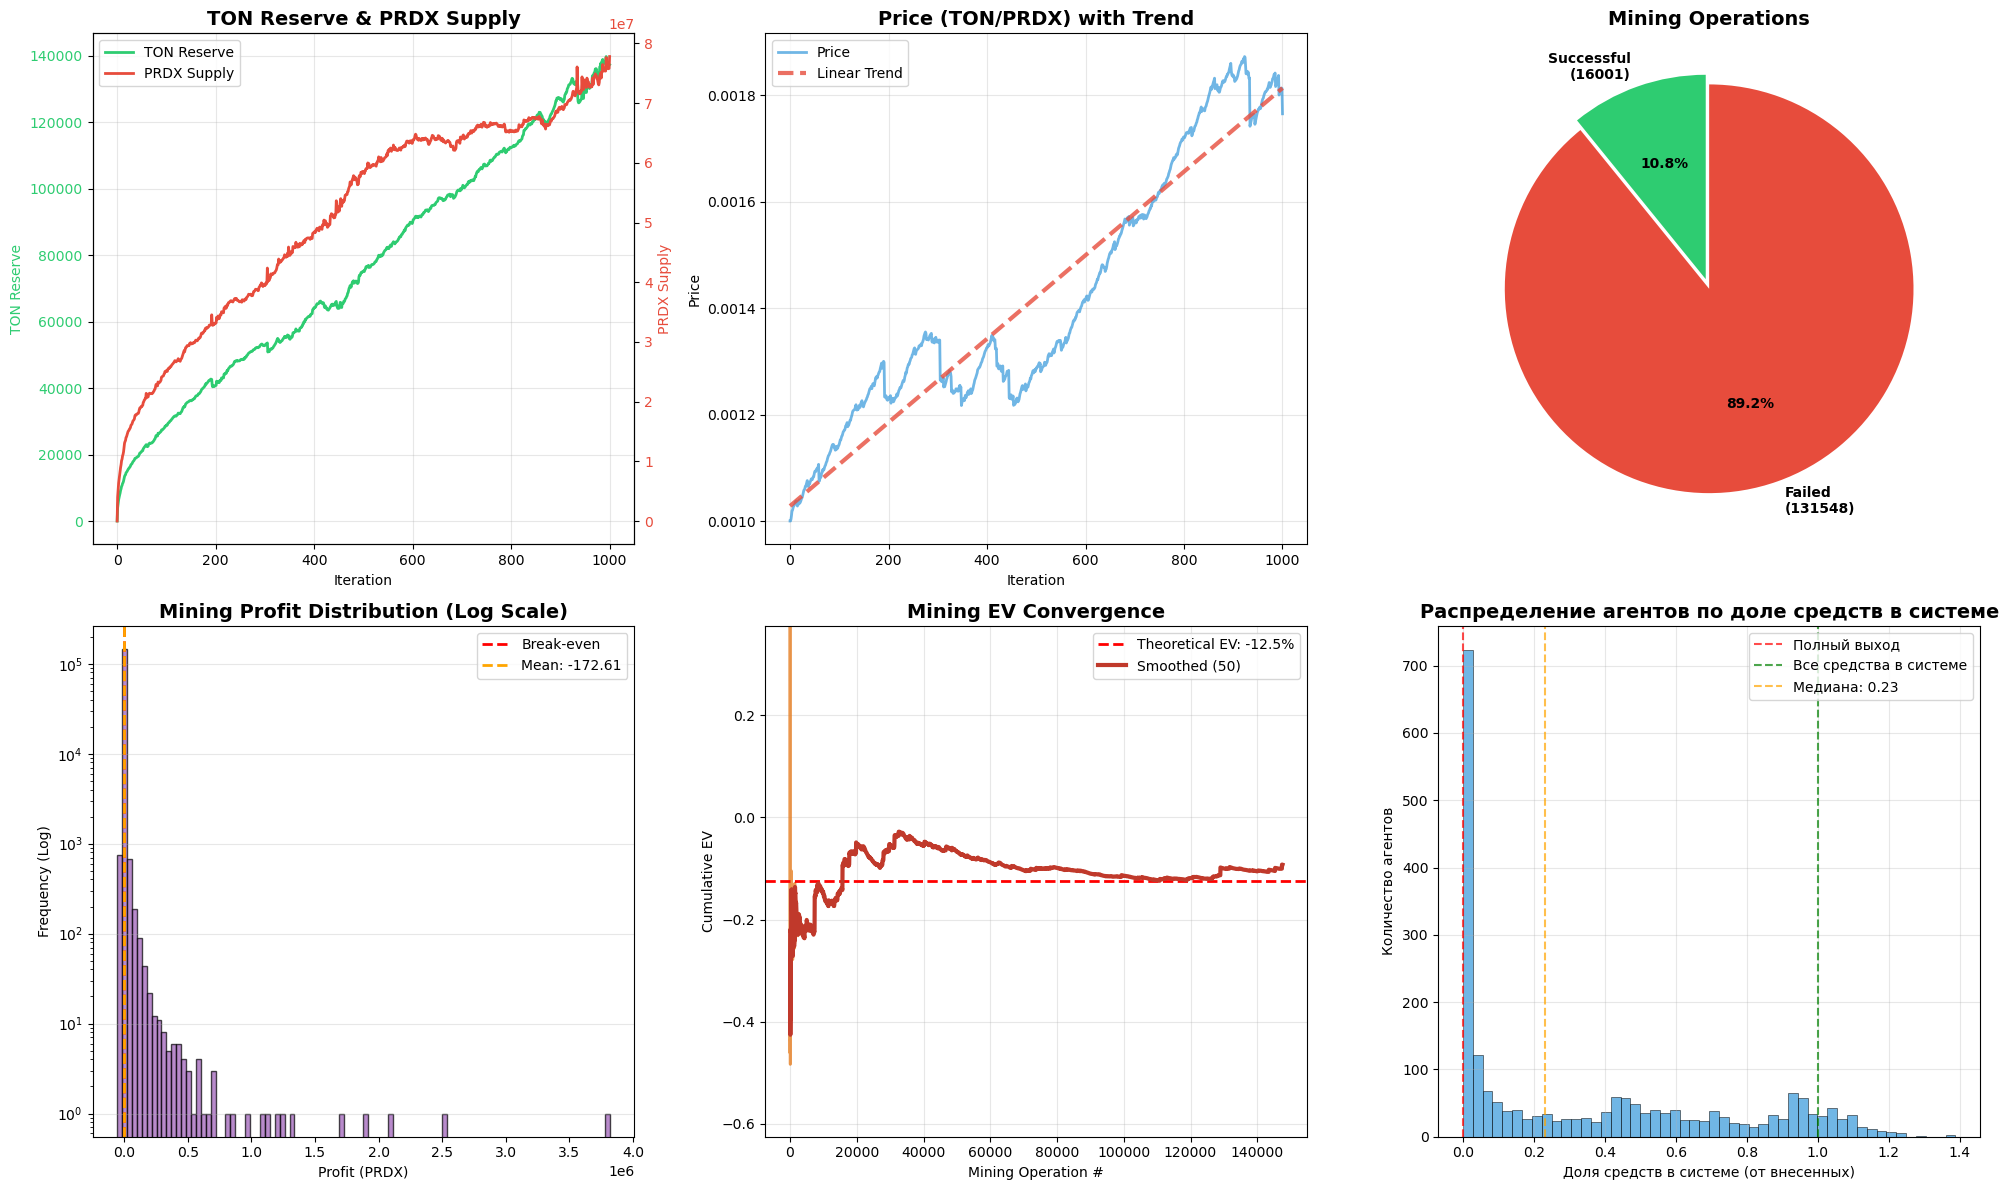

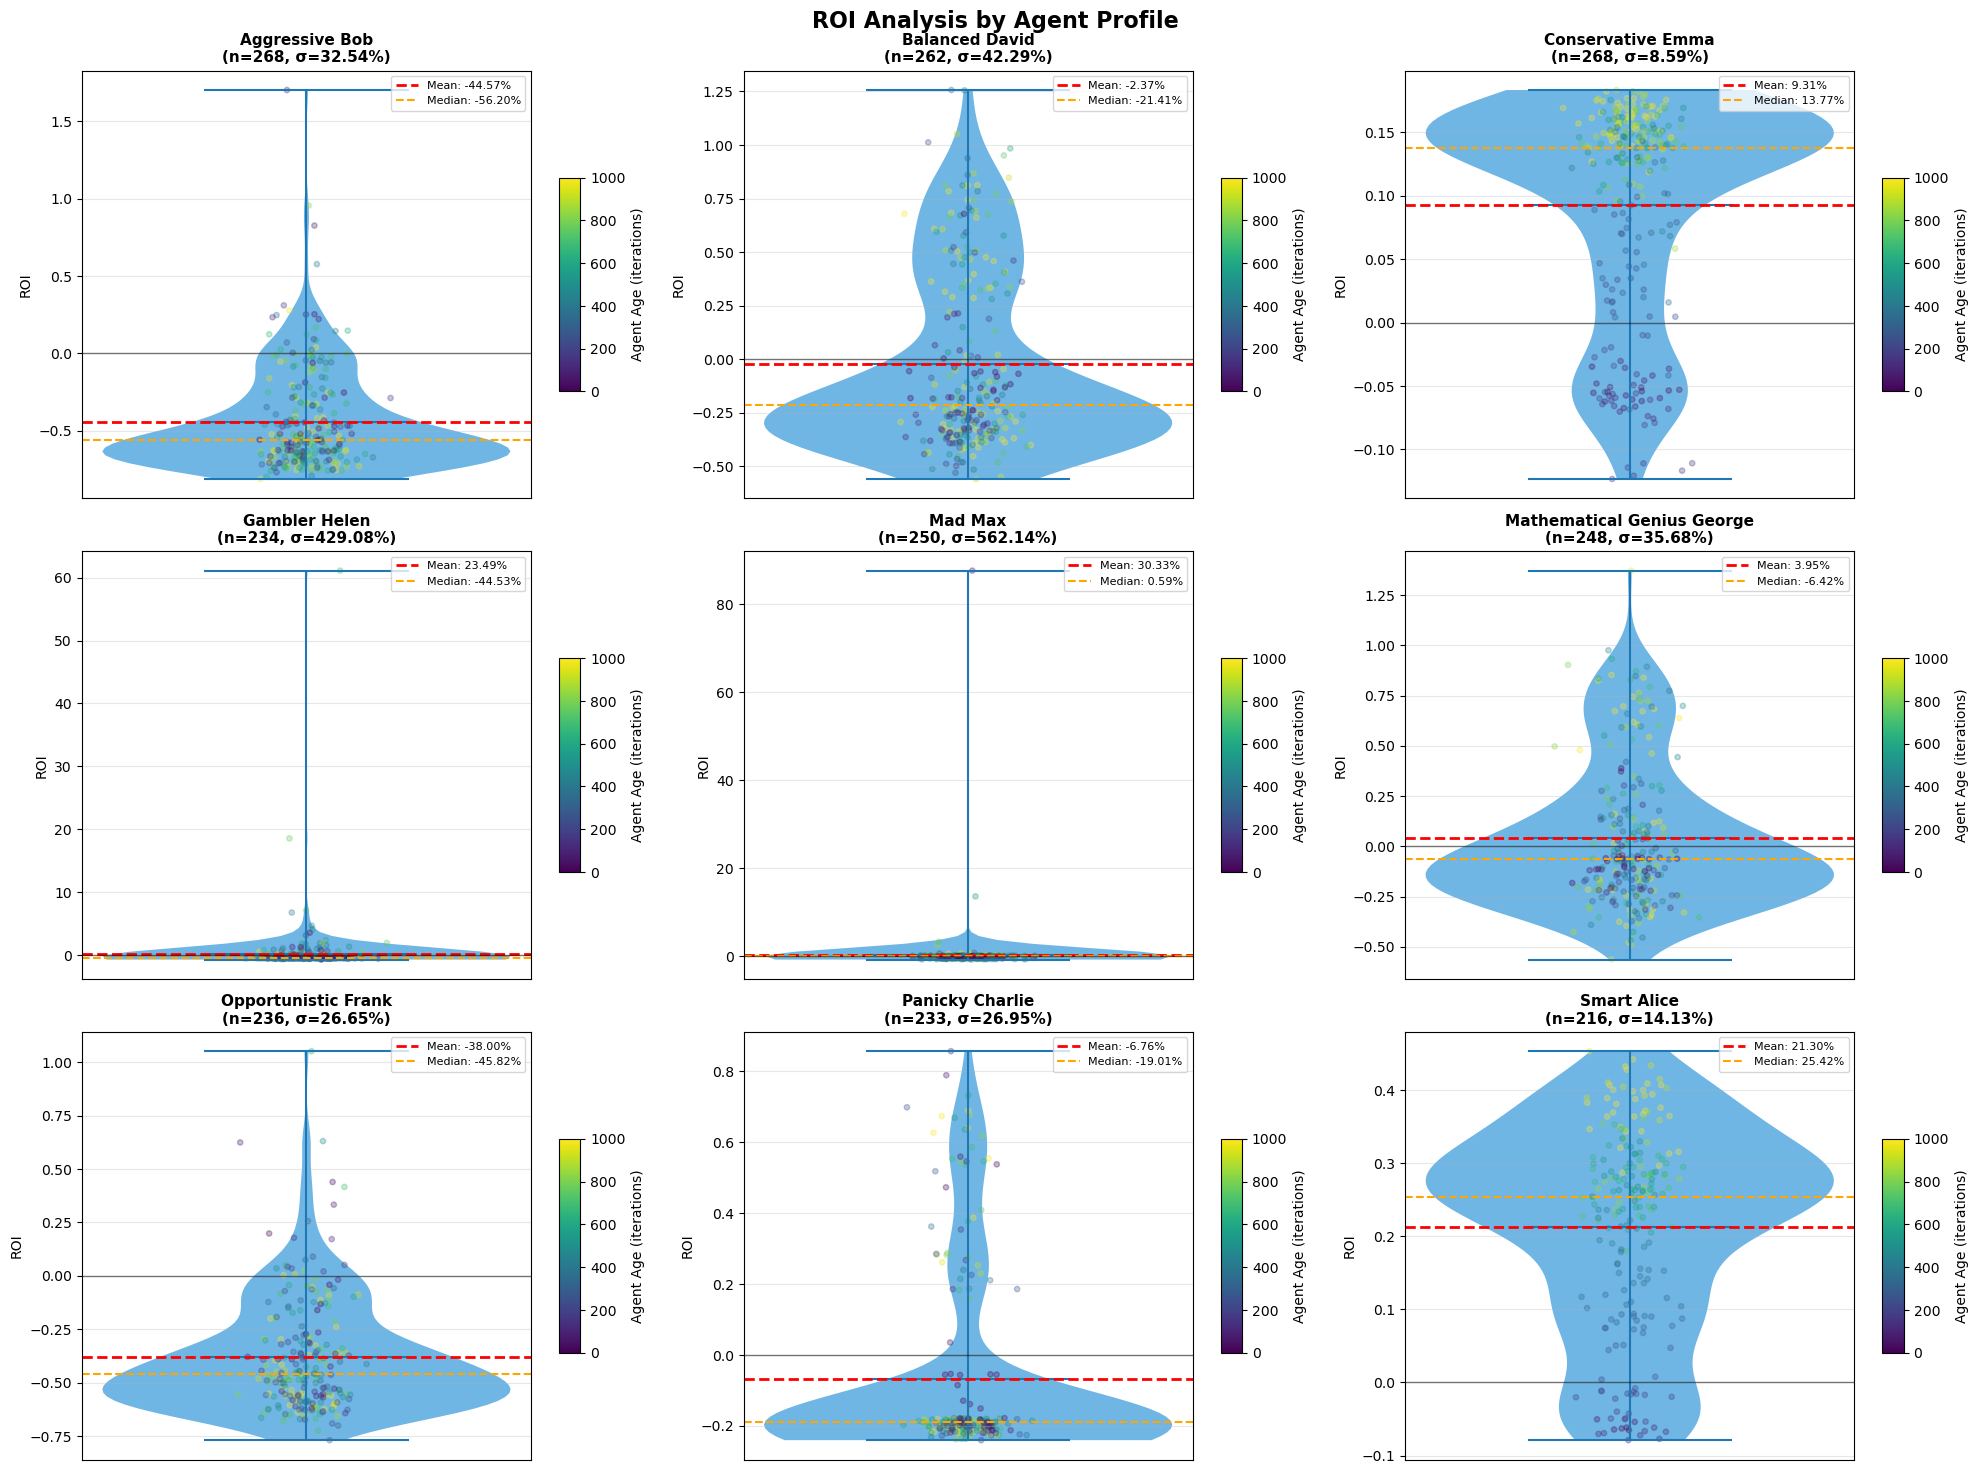


ДЕТАЛЬНАЯ СТАТИСТИКА

Действия агентов:
 HOLD                : 713915
 MINE                : 147549
 MINT                :  80611
 MINE_FAILED         :  52972
 BURN                :  35055

ROI по профилям:

 Aggressive Bob:
 Агентов: 268
 Среднее:  -44.57%
 Медиана:  -56.20%
 Std Dev:   32.54%
 Min:  -81.16%
 Max:  170.14%
 Q25:  -66.38%
 Q75:  -28.78%

 Balanced David:
 Агентов: 262
 Среднее:   -2.37%
 Медиана:  -21.41%
 Std Dev:   42.29%
 Min:  -56.04%
 Max:  125.68%
 Q25:  -33.57%
 Q75:   31.97%

 Conservative Emma:
 Агентов: 268
 Среднее:    9.31%
 Медиана:   13.77%
 Std Dev:    8.59%
 Min:  -12.35%
 Max:   18.35%
 Q25:    3.46%
 Q75:   15.56%

 Gambler Helen:
 Агентов: 234
 Среднее:   23.49%
 Медиана:  -44.53%
 Std Dev:  429.08%
 Min:  -71.07%
 Max: 6112.10%
 Q25:  -51.85%
 Q75:  -29.17%

 Mad Max:
 Агентов: 250
 Среднее:   30.33%
 Медиана:    0.59%
 Std Dev:  562.14%
 Min:  -79.50%
 Max: 8770.71%
 Q25:  -40.76%
 Q75:   11.34%

 Mathematical Genius George:
 Агентов: 248
 Средне

In [53]:
# ═══════════════════════════════════════════════════════════
# ЗАПУСК СИМУЛЯЦИИ
# ═══════════════════════════════════════════════════════════

if __name__ == "__main__":
    # Установка seed для воспроизводимости
    np.random.seed(777)
   
    # КОНФИГУРАЦИЯ СИМУЛЯЦИИ - все параметры здесь для удобства настройки
    sim = Simulation(
        profile_counts={
            "Smart Alice": 30,
            "Aggressive Bob": 20,
            "Mad Max": 20,
            "Panicky Charlie": 25,
            "Balanced David": 40,
            "Conservative Emma": 25,
            "Opportunistic Frank": 20,
            "Mathematical Genius George": 30,
            "Gambler Helen": 10,
        },
        new_agents_per_iteration=2,
        iterations=1000
    )
   
    # Запуск симуляции
    sim.run()
   
    # Визуализация результатов
    sim.plot_results()